In [4]:
import pandas as pd
df = pd.read_csv("../data/netflix_cleaned.csv")
print(f"Shape of data frame: {df.shape}")
df.head(10)

Shape of data frame: (8807, 22)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,date_added_parsed,year_added,month_added,month_name_added,date_added_clean,duration_num,duration_type,primary_genre,country_clean,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,...,2021-09-25,2021.0,9.0,September,"September 25, 2021",90.0,minutes,Documentaries,United States,United States
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",2.0,seasons,International TV Shows,South Africa,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",1.0,seasons,Crime TV Shows,NaN,Unknown
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",1.0,seasons,Docuseries,NaN,Unknown
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",2.0,seasons,International TV Shows,India,India
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",1.0,seasons,TV Dramas,NaN,Unknown
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",91.0,minutes,Children & Family Movies,NaN,Unknown
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",125.0,minutes,Dramas,"United States, Ghana, Burkina Faso, United Kin...",United States
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",9.0,seasons,British TV Shows,United Kingdom,United Kingdom
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",104.0,minutes,Comedies,United States,United States


In [5]:
df['type'].value_counts()


type
Movie      6131
TV Show    2676
Name: count, dtype: int64

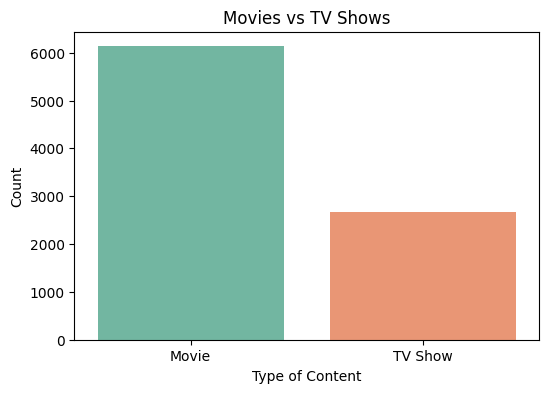

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize= (6,4))
sns.countplot(data=df, x='type', hue = 'type', palette='Set2', legend = False)

plt.title("Movies vs TV Shows")
plt.xlabel("Type of Content")
plt.ylabel("Count")
plt.savefig("../visuals/movies_vs_tvshows.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
top_genres = df['primary_genre'].value_counts().head(10)
top_genres

primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

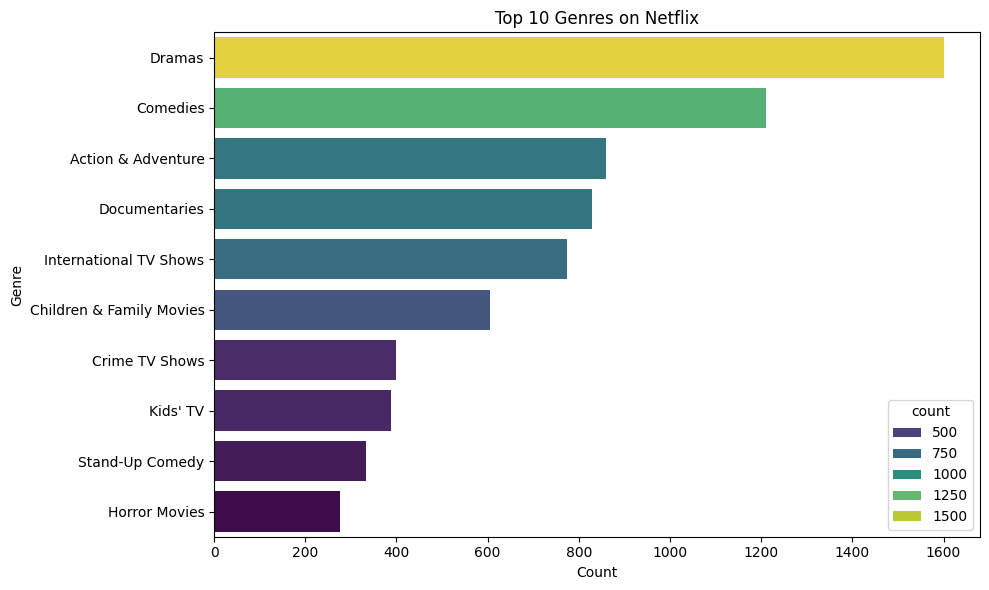

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue = top_genres,
    palette="viridis"
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("../visuals/top_genres.png", dpi=300, bbox_inches='tight')
plt.show()


In [19]:
top_countries = df['primary_country'].value_counts().head(10)
top_countries


primary_country
United States     3211
India             1008
Unknown            831
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64

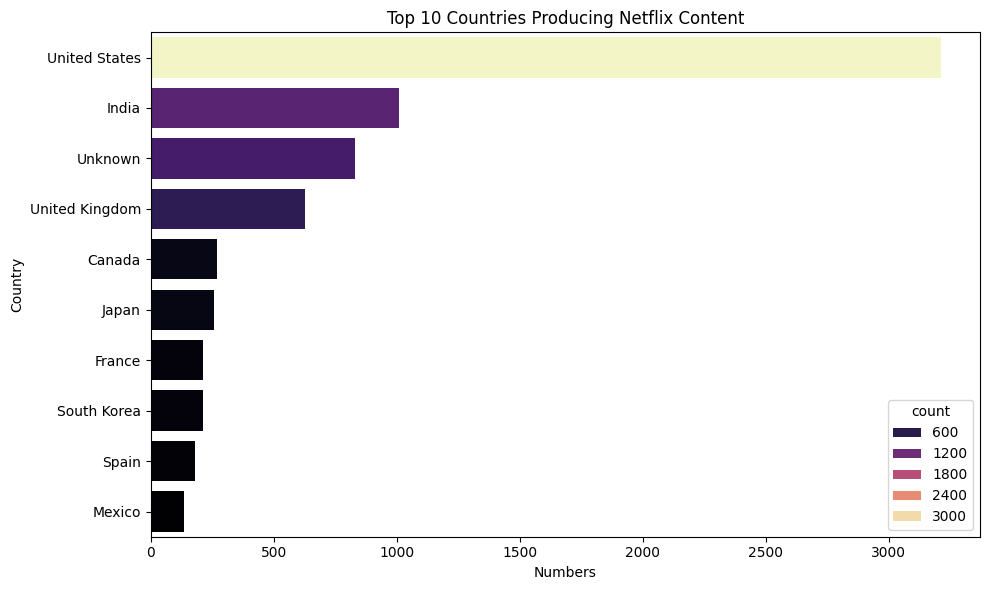

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue = top_countries,
    palette="magma"
)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Numbers")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig("../visuals/top_countries.png", dpi=300, bbox_inches='tight')
plt.show()


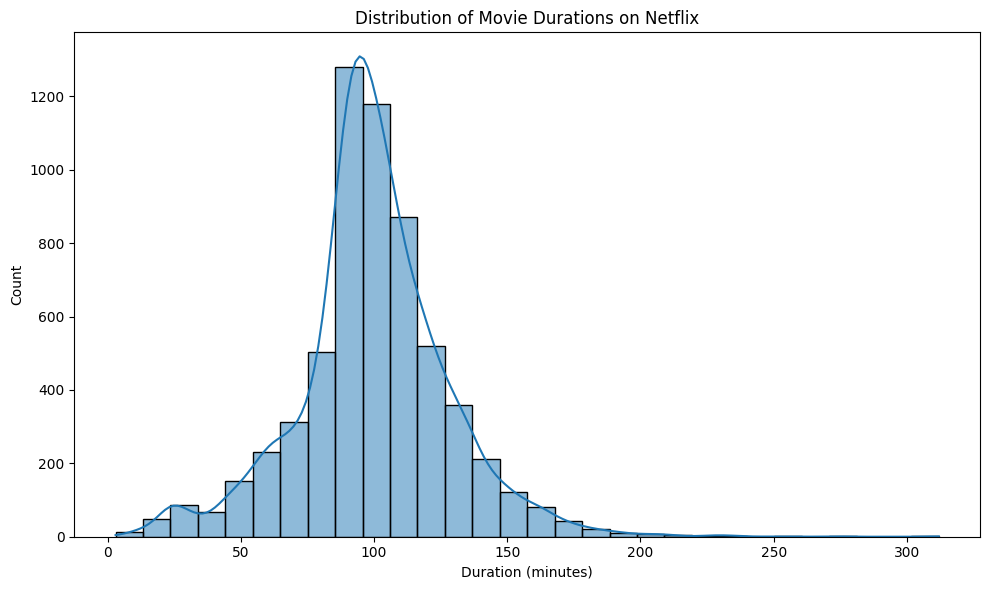

In [23]:
movie_df = df[df['duration_type'] == "minutes"]

plt.figure(figsize=(10,6))
sns.histplot(movie_df['duration_num'], bins=30, kde=True)

plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../visuals/movie_duration_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


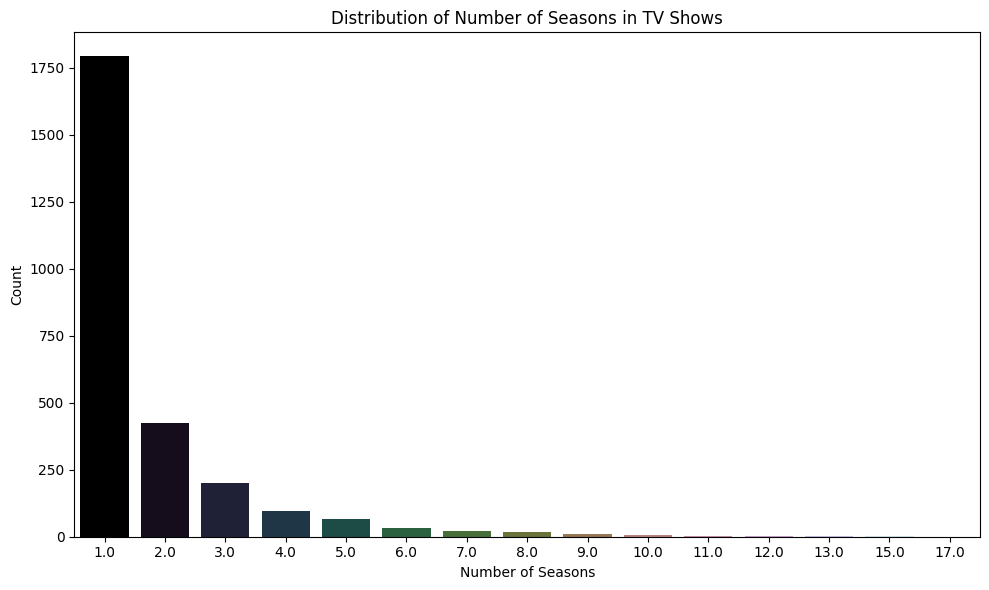

In [26]:
tv_df = df[df['duration_type'] == "seasons"]

plt.figure(figsize=(10,6))

sns.countplot(
    data=tv_df,
    x='duration_num',
    hue='duration_num',     
    palette='cubehelix',
    legend=False            
)

plt.title("Distribution of Number of Seasons in TV Shows")
plt.xlabel("Number of Seasons")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../visuals/tvshow_seasons_distribution.png", dpi=300, bbox_inches='tight')
plt.show()